In [1]:
!pip install -r ../requirements.txt

import sys
sys.path.append('../src')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import math

import pandas as pd
import numpy as np


In [2]:
from mcTOTHelper import MCTOTHelper

#Get an instance of the helper class, using this particular calibration file
TOThelper = MCTOTHelper("../calibrations/mc_v8_tot_calibration_averaged.csv")

In [3]:
mcdata = pd.read_csv('../analysis_files/muon_4GeV_MC_v8.csv')

[5.80440281e+02 4.77281733e+01 1.32298915e+05 5.73337588e-01]
Mode: 564.0692640692641


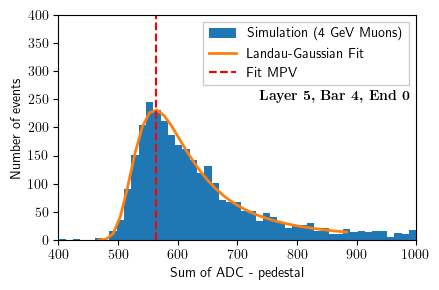

In [103]:
"""
Messy code sorry
But all it does is load muon data from some particular channel
And plots the MIP peak and makes a Landau-Gaussian fit to it
In order to give you a gain calibration
"""

layer = 5
strip = 4
end = 0

events = mcdata.loc[mcdata['layer'] == layer].loc[mcdata['strip'] == strip]

sum_adc = []
max_adc = []
tot = []
tot_corrected = []

#Go through each pulse
for index, row in events.iterrows():
    #Check if this pulse is in TOT mode (returns -1 otherwise)
    #if TOThelper.get_Tc_index(row,end) != -1:
    #    #If so, get the TOT value out of the pulse
    #    #rawtot = TOThelper.get_TOT(row,end)
    #    #tot.append(rawtot)
    #    #And correct it to sum of ADC
    #    #tot_corrected.append(TOThelper.correct_TOT(layer,strip,end,rawtot))
    #    pass
    #else:
    #sum_adc.append(row["adc_sum_end"+str(end)])
    sum_adc.append((row["adc_sum_end0"]+row["adc_sum_end1"])/2-800)
    #max_adc.append(row["adc_max_end"+str(end)])
    max_adc.append((row["adc_max_end0"]+row["adc_max_end1"])/2-100)

fig, axs = plt.subplots(1,1, figsize=(4.5,3))
adcbins = np.linspace(400,1000,50)
maxadcbins = np.linspace(50,300,50)
xaxis = [(adcbins[k]+adcbins[k+1])/2 for k in range(0,len(adcbins)-1)]
xaxismax = [(maxadcbins[k]+maxadcbins[k+1])/2 for k in range(0,len(maxadcbins)-1)]

#sum_adc = [x for x in sum_adc if x > 1200 and x < 2000]

y = axs.hist(sum_adc, bins=adcbins, label=r"Simulation (4 GeV Muons)")
#y_max = axs[1].hist(max_adc, bins=maxadcbins, label="Simulation (4 GeV Muons)")
y = list(y[0])
#y_max = list(y_max[0])
#axs[0].set_yscale("log")
axs.set_xlabel("Sum of ADC - pedestal")
#axs[1].set_xlabel("Max ADC - pedestal")
"""
totbins = np.linspace(0,4096, 50)
axs[1].hist(tot, bins=totbins)
axs[1].set_xlabel("Raw TOT")

#combinedhistbins = np.linspace(500,max(tot_corrected),100)
#axs[2].hist(sum_adc, bins=combinedhistbins, histtype="step", label="ADC")
#axs[2].hist(tot_corrected,bins=combinedhistbins, label="Corrected TOT")
#axs[2].set_yscale("log")
#axs[2].set_xlabel("Sum of ADC")
#axs[2].legend()
"""

#axs.set_title("Layer " + str(layer) + " Strip " + str(strip) + " End " + str(end))


#plt.hist(max_adc,bins=75)
#plt.yscale("log")

#axs[0].plot(xaxis,y)
#axs[1].plot(xaxismax,y_max)

from scipy.stats import landau, norm
from scipy.optimize import curve_fit
from scipy.signal import convolve

xaxis_cut = xaxis[5:40]
y_cut = y[5:40]

#xaxis_cut_max = xaxismax[4:30]
#y_cut_max = y_max[4:30]

xgrid = np.linspace(xaxis_cut[0],xaxis_cut[-1],100)
gaussgrid = np.linspace(-100,100,100)

#xgridmax = np.linspace(xaxis_cut_max[0],xaxis_cut_max[-1],100)
#gaussgridmax = np.linspace(-100,100,100)
#print(xgrid)

def f(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgrid],[norm.pdf(k,0.0,e) for k in gaussgrid], mode='same')
    return np.interp(x,xgrid,convolved)

def fmax(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgridmax],[norm.pdf(k,0.0,e) for k in gaussgridmax], mode='same')
    return np.interp(x,xgridmax,convolved)

p = curve_fit(f, xaxis_cut,y_cut, p0=[550,20,10000,20])
#pmax = curve_fit(fmax, xaxis_cut_max,y_cut_max,p0=[100,100,10,20])

print(p[0])
axs.plot(xaxis_cut, [f(x,*p[0]) for x in xaxis_cut], label="Landau-Gaussian Fit",linewidth=2)
#axs[1].plot(xaxis_cut_max, [fmax(x,*pmax[0]) for x in xaxis_cut_max], label="Landau-Gaussian Fit")
#axs[0].ylim((0,500))

xmode = 0.0
mode = 0.0
for k in xgrid:
    if f(k,*p[0]) > mode:
        mode = f(k,*p[0])
        xmode = k
axs.vlines(xmode,0,500, linestyle="dashed", color="red", label="Fit MPV")
#axs[1].vlines(xmodemax,0,500, linestyle="dashed", color="red", label="Fit MPV")
print("Mode: " + str(xmode))

plt.rcParams.update({
    'text.usetex':True
    })

axs.set_xlim(400,1000)
axs.set_ylim(0,400)
axs.set_ylabel("Number of events")
axs.legend(fancybox=False,framealpha=1.0)
axs.text(0.56,0.62,r"\bf{Layer 5, Bar 4, End 0}",transform=axs.transAxes)

#axs[1].legend( bbox_to_anchor=(1.05, 1.0),ncol=1)
plt.tight_layout()
plt.savefig("plots/datamccomparisons/montecarlogain.pdf")
plt.show()



In [230]:
adc_max_5mm = max_adc

/tmp/ipykernel_588455/2367001741.py:8: RuntimeWarning: invalid value encountered in sqrt
  sum_adc_noise_5mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_5mm]
/tmp/ipykernel_588455/2367001741.py:9: RuntimeWarning: invalid value encountered in sqrt
  sum_adc_noise_10mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_10mm]
/tmp/ipykernel_588455/2367001741.py:10: RuntimeWarning: invalid value encountered in sqrt
  sum_adc_noise_20mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_20mm]


[1.39385386e+03 5.51305364e+01 1.73443432e+05 5.94965702e-01]


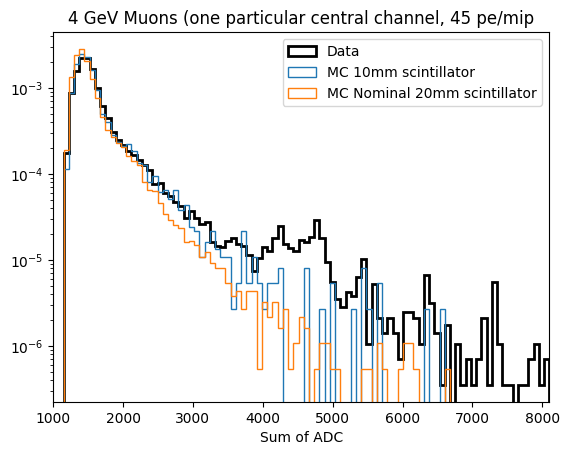

In [284]:
import json
file = open("muonadc.json","r")
data = json.load(file)
file.close()

data = [x for x in data if x > 1200]

sum_adc_noise_5mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_5mm]
sum_adc_noise_10mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_10mm]
sum_adc_noise_20mm = [x+(x-800)*0.0+scipy.stats.norm.rvs()*np.sqrt(((x+(x-800)*0.0)-800)/600*pe_per_mip)*600/pe_per_mip for x in adc_sum_20mm]

sum_adc_filtered = [x for x in sum_adc if x > 1200]
#sum_adc_filtered_5mm = [x+(x-800)*0.05 for x in adc_sum_5mm if x > 1200]
sum_adc_filtered_10mm = [x for x in sum_adc_noise_10mm if x > 1200]
sum_adc_filtered_20mm = [x for x in sum_adc_noise_20mm if x > 1200]
#sum_adc_filtered = sum_adc

import scipy.stats

pe_per_mip = 45



#data = [min(3200,x) for x in data]
#sum_adc_noise_5mm = [min(3200,x) for x in sum_adc_noise_5mm]
#sum_adc_noise_10mm = [min(3200,x) for x in sum_adc_noise_10mm]
#sum_adc_noise_20mm = [min(3200,x) for x in sum_adc_noise_20mm]

#sum_adc_pileup = []
#for x in sum_adc_noise:
#    if scipy.stats.uniform.rvs() < 0.05:
#        sum_adc_pileup.append(x+600)
#    else:
#        sum_adc_pileup.append(x)

bins = np.linspace(700,8100,100)

plt.hist(data, bins=bins, histtype="step",label="Data", density=True, color="black",linewidth=2)
#plt.hist(sum_adc_filtered, bins=bins, histtype="step", label="MC", density=True)
#h = plt.hist(sum_adc_noise_5mm, bins=bins, histtype="step", label="MC 5mm scintillator", density=True)
h = plt.hist(sum_adc_filtered_10mm, bins=bins, histtype="step", label="MC 10mm scintillator", density=True)
h = plt.hist(sum_adc_filtered_20mm, bins=bins, histtype="step", label="MC Nominal 20mm scintillator", density=True)
#plt.hist(sum_adc_pileup, bins=bins, histtype="step", label="MC", density=True)

xaxis = [(bins[k]+bins[k+1])/2 for k in range(0,len(bins)-1)]

xaxis_cut = xaxis[10:40]
y_cut = h[0][10:40]
#muon_4GeV_MC_v7_5mm.csv
xgrid = np.linspace(xaxis_cut[0],xaxis_cut[-1],100)
gaussgrid = np.linspace(-100,100,100)
#print(xgrid)

def f(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgrid],[norm.pdf(k,0.0,e) for k in gaussgrid], mode='same')
    return np.interp(x,xgrid,convolved)

#p = curve_fit(f, xaxis_cut,y_cut, p0=[1350,20,0.002,20])

print(p[0])
#plt.plot(xaxis_cut, [f(x,*p[0]) for x in xaxis_cut])
#plt.plot(xaxis_cut, [f(x,*[1400,5,5,1]) for x in xaxis_cut])

plt.yscale("log")
plt.legend()
#plt.xticks([0,2000,3200,4000,6000,8000,10000])
#plt.ylim(1e-6,5e-3)
#plt.xlim(1000,1023*8)
plt.xlim(1000,8100)
plt.title("4 GeV Muons (one particular central channel, 45 pe/mip")
plt.xlabel("Sum of ADC")
#plt.ylim(0,0.0005)
plt.show()

[1.39385386e+03 5.51305364e+01 1.73443432e+05 5.94965702e-01]


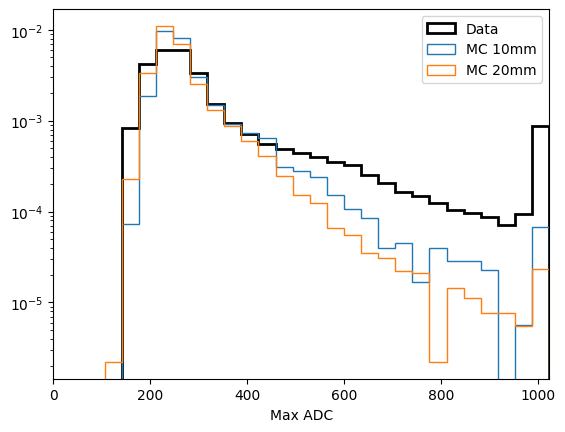

In [288]:
import json
file = open("muonadcmax.json","r")
data = json.load(file)
file.close()

data = [x for x in data if x > 150]
max_adc_filtered_5mm = [x + (x-100)*0.2 for x in adc_max_5mm if x > 150]
max_adc_filtered_10mm = [x + (x-100)*0.2 for x in adc_max_10mm if x > 150]
max_adc_filtered_20mm = [x + (x-100)*0.2 for x in adc_max_20mm if x > 150]
#sum_adc_filtered = sum_adc

import scipy.stats

pe_per_mip = 30

#max_adc_noise = [x+scipy.stats.norm.rvs()*np.sqrt((x-100)/100*pe_per_mip)*100/pe_per_mip for x in max_adc_filtered]
#max_adc_noise = [min(1023,x) for x in max_adc_noise]
max_adc_noise_5mm = [x+scipy.stats.norm.rvs()*np.sqrt((x-100)/100*pe_per_mip)*100/pe_per_mip for x in max_adc_filtered_5mm]
max_adc_noise_5mm = [min(1023,x) for x in max_adc_noise_5mm]
max_adc_noise_10mm = [x+scipy.stats.norm.rvs()*np.sqrt((x-100)/100*pe_per_mip)*100/pe_per_mip for x in max_adc_filtered_10mm]
max_adc_noise_10mm = [min(1023,x) for x in max_adc_noise_10mm]
max_adc_noise_20mm = [x+scipy.stats.norm.rvs()*np.sqrt((x-100)/100*pe_per_mip)*100/pe_per_mip for x in max_adc_filtered_20mm]
max_adc_noise_20mm = [min(1023,x) for x in max_adc_noise_20mm]

#sum_adc_pileup = []
#for x in sum_adc_noise:
#    if scipy.stats.uniform.rvs() < 0.05:
#        sum_adc_pileup.append(x+600)
#    else:
#        sum_adc_pileup.append(x)

bins = np.linspace(0,1023,30)

plt.hist(data, bins=bins, histtype="step",label="Data", density=True,color="black",linewidth=2)
#plt.hist(sum_adc_filtered, bins=bins, histtype="step", label="MC", density=True)
#h = plt.hist(max_adc_noise_5mm, bins=bins, histtype="step", label="MC 5mm", density=True)
h = plt.hist(max_adc_noise_10mm, bins=bins, histtype="step", label="MC 10mm", density=True)
h = plt.hist(max_adc_noise_20mm, bins=bins, histtype="step", label="MC 20mm", density=True)
#plt.hist(sum_adc_pileup, bins=bins, histtype="step", label="MC", density=True)

xaxis = [(bins[k]+bins[k+1])/2 for k in range(0,len(bins)-1)]

xaxis_cut = xaxis[10:40]
y_cut = h[0][10:40]
#muon_4GeV_MC_v7_5mm.csv
xgrid = np.linspace(xaxis_cut[0],xaxis_cut[-1],100)
gaussgrid = np.linspace(-100,100,100)
#print(xgrid)

def f(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgrid],[norm.pdf(k,0.0,e) for k in gaussgrid], mode='same')
    return np.interp(x,xgrid,convolved)

#p = curve_fit(f, xaxis_cut,y_cut, p0=[1350,20,0.002,20])

print(p[0])
#plt.plot(xaxis_cut, [f(x,*p[0]) for x in xaxis_cut])
#plt.plot(xaxis_cut, [f(x,*[1400,5,5,1]) for x in xaxis_cut])

plt.yscale("log")
plt.legend()
#plt.xticks([0,2000,3200,4000,6000,8000,10000])
#plt.ylim(1e-6,5e-3)
#plt.xlim(1000,1023*8)
plt.xlim(0,1023)
plt.xlabel("Max ADC")
plt.show()